# Analisis Tren Topik ArXiv Temporal (Tahunan)

Notebook ini menganalisis pergeseran popularitas relatif dari 15 klaster/topik akademis arXiv yang sudah diidentifikasi dari tahun 1993 hingga 2026.

**Metodologi:**
1. **Ekstraksi Tahun Terbit**: Mengekstrak tahun publikasi langsung dari kolom `id` paper secara efisien (menggunakan format ID lama & baru).
2. **Pembersihan Data**: Membatasi analisis pada rentang waktu valid (1993 s.d. 2026).
3. **Agregasi Data**: Menghitung jumlah paper absolut dan proporsi persentase relatif per topik per tahun.
4. **Visualisasi Tren (8 Grafik Utama)**: Membuat plot garis, heatmap, grafik area bertumpuk, laju pertumbuhan/penurunan (velocity), linimasa topik dominan, box plot distribusi usia klaster, serta grafik akumulasi kumulatif.

In [1]:
# Impor library yang dibutuhkan
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style seaborn
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

## Bagian 1: Ekstraksi Tahun Publikasi & Unit Test
Kita menulis fungsi untuk mengambil tahun publikasi dari string ID arXiv.

In [2]:
def extract_year_from_id(arxiv_id):
    """Extract publication year from arXiv ID (supports pre- and post-2007 formats)."""
    if not arxiv_id or not isinstance(arxiv_id, str):
        return None
    arxiv_id = arxiv_id.strip()
    
    # Format lama dengan kategori (misal: hep-ph/0302123)
    if '/' in arxiv_id:
        parts = arxiv_id.split('/')
        if len(parts) >= 2:
            num_part = parts[-1]
            if len(num_part) >= 4:
                yy_str = num_part[:2]
                try:
                    yy = int(yy_str)
                    return 1900 + yy if yy >= 93 else 2000 + yy
                except ValueError:
                    pass
    else:
        # Format baru numerik (misal: 0704.0001 atau 2101.12345)
        cleaned = arxiv_id.replace('.', '')
        if len(cleaned) >= 4:
            yy_str = cleaned[:2]
            try:
                yy = int(yy_str)
                return 1900 + yy if yy >= 93 else 2000 + yy
            except ValueError:
                pass
    return None

In [3]:
def test_year_parser():
    assert extract_year_from_id("0704.0001") == 2007
    assert extract_year_from_id("hep-ph/0302123") == 2003
    assert extract_year_from_id("9301123") == 1993
    assert extract_year_from_id("math/9903120") == 1999
    assert extract_year_from_id("2101.12345") == 2021
    assert extract_year_from_id(None) is None
    assert extract_year_from_id("") is None
    print("Unit Test Parser Tahun Passed!")

test_year_parser()

Unit Test Parser Tahun Passed!


## Bagian 2: Agregasi Data & Metrik Kecepatan (Velocity)
Kita memuat berkas hasil clustering, memparsing tahunnya, lalu menghitung proporsi persentase popularitas setiap klaster dari tahun ke tahun.

In [4]:
CSV_PATH = "../01_Clustering_and_Labelling/arxiv_clustered_results.csv"
JSON_MAP_PATH = "../01_Clustering_and_Labelling/cluster_names.json"
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

if os.path.exists(CSV_PATH) and os.path.exists(JSON_MAP_PATH):
    print("Memuat dataset...")
    df = pd.read_csv(CSV_PATH, dtype={'id': str}, low_memory=False)
    with open(JSON_MAP_PATH, "r", encoding="utf-8") as f:
        cluster_names = json.load(f)
        
    print("Mengekstrak tahun publikasi...")
    df['year'] = df['id'].astype(str).apply(extract_year_from_id)
    
    # Filter data tahun valid
    df = df[(df['year'] >= 1993) & (df['year'] <= 2026)]
    
    # Map ID klaster ke nama label akademik
    df['cluster_name'] = df['cluster'].astype(str).map(cluster_names)
    print(f"Total dokumen valid untuk analisis tren: {len(df):,}")
else:
    print("File data CSV hasil prediksi atau file JSON pemetaan nama klaster tidak ditemukan.")
    print("Silakan pastikan Anda sudah menyelesaikan run prediksi massal di notebook 01 terlebih dahulu.")

Memuat dataset...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_27624\56251726.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


Mengekstrak tahun publikasi...
Total dokumen valid untuk analisis tren: 2,931,651


In [5]:
if 'df' in locals():
    # Hitung matriks jumlah paper (Tahun vs Klaster)
    pivot_df = pd.crosstab(df['year'], df['cluster_name'])
    # Hitung persentase relatif popularitas per tahun
    pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100
    print("Tabel persentase popularitas relatif berhasil dihitung.")
    display(pivot_pct.tail(5))

Tabel persentase popularitas relatif berhasil dihitung.


cluster_name,"AI Generatif, Difusi & Retrieval (Generative AI, Diffusion & Information Retrieval)","Aljabar, Teori Grup & Teori Representasi (Algebra & Group Theory)",Astrofisika & Astronomi (Astrophysics & Astronomy),Fisika Benda Terkondensasi & Ilmu Bahan (Condensed Matter & Materials Science),Fisika Energi Tinggi Teoretis (Theoretical High Energy Physics),Fisika Fenomenologi & Sistem Kompleks (Phenomenology & Complex Systems),Fisika Kuantum & Informasi Kuantum (Quantum Physics & Information),"Gravitasi, Kosmologi & Fisika Energi Tinggi (General Relativity & Cosmology)",Kosmologi & Fenomenologi Partikel (Cosmology & Particle Physics Phenomenology),Pembelajaran Mesin & Deep Learning Utama (Machine Learning & Deep Learning),Pemrosesan Bahasa Alami & AI Core (Natural Language Processing & Core AI),Persamaan Diferensial & Analisis Numerik (Differential Equations & Numerical Analysis),"Sistem Kontrol, Optimasi & Sistem Dinamis (Control Systems & Optimization)",Topik Multidisiplin & Umum (Multidisciplinary & General Science),Visi Komputer & Jaringan Saraf (Computer Vision & Neural Networks)
year,,,,,,,,,,,,,,,
2022,5.999181,3.576891,7.827478,1.601577,34.038085,3.402947,2.559076,19.628740,2.269349,4.010404,6.443466,3.356095,1.378088,2.609159,1.299464
2023,5.638106,3.365597,7.744662,1.492144,31.741266,3.385741,4.339735,21.424323,2.165071,3.661052,6.058746,3.865376,1.455691,2.465322,1.197168
2024,4.949822,3.092665,7.254466,1.393687,29.526409,3.276250,6.050920,24.158604,2.014515,3.340996,5.459597,4.435538,1.470317,2.488229,1.087985
2025,4.671583,3.000499,7.014756,1.309379,27.544062,3.340410,6.062513,27.609443,2.000098,2.852161,5.045239,4.285624,1.622927,2.606104,1.035200
2026,4.314553,2.617907,6.258626,1.301099,28.309413,3.269859,5.744695,29.704209,1.981665,2.585926,4.779672,3.742832,1.783049,2.644838,0.961657


## Bagian 3: Pembuatan Visualisasi Tren (8 Grafik)
Mari kita gambarkan dan simpan 8 visualisasi tren akademis temporal.

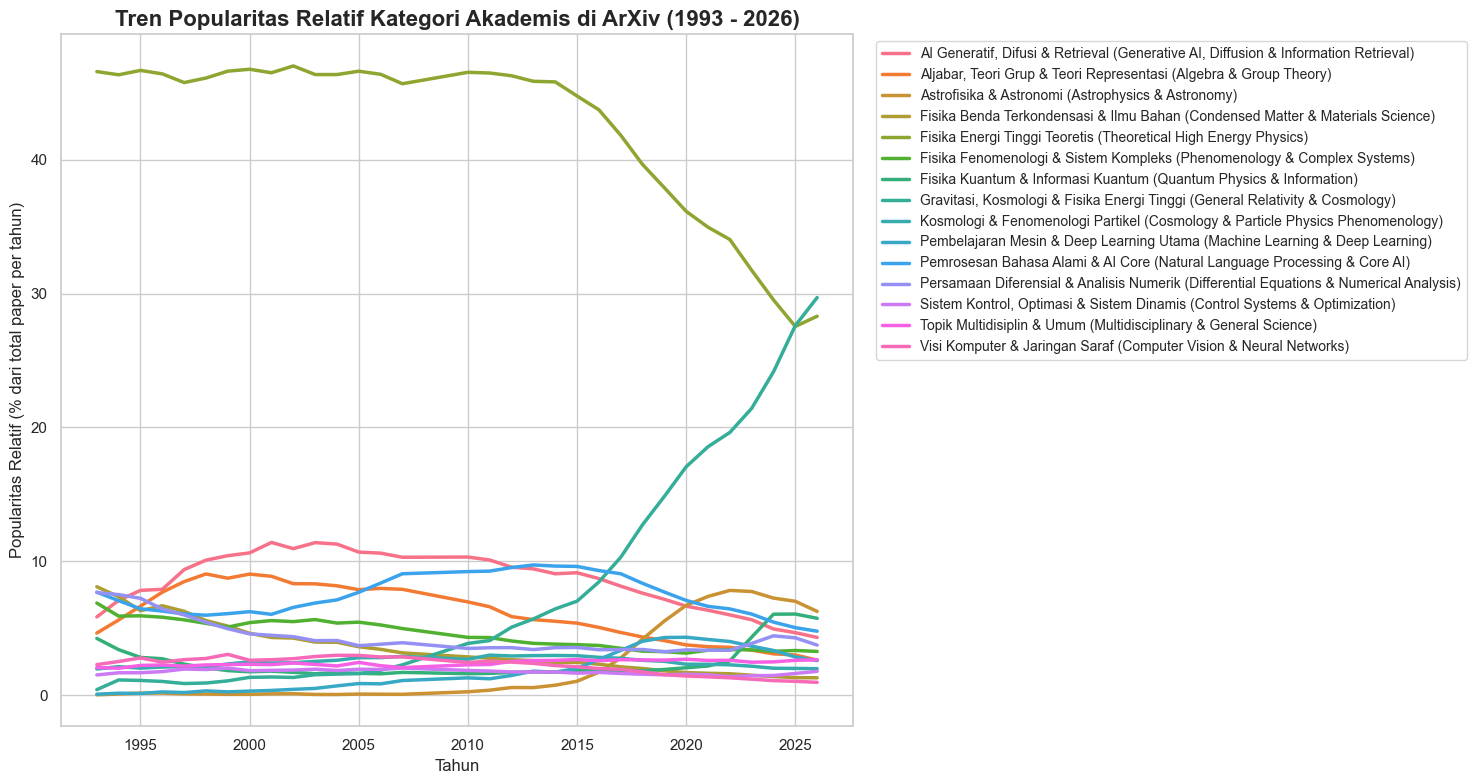

In [6]:
if 'pivot_pct' in locals():
    # Grafik 1: Line Plot Tren Relatif
    plt.figure(figsize=(15, 8))
    sns.lineplot(data=pivot_pct, dashes=False, linewidth=2.5)
    plt.title("Tren Popularitas Relatif Kategori Akademis di ArXiv (1993 - 2026)", fontsize=16, fontweight='bold')
    plt.xlabel("Tahun", fontsize=12)
    plt.ylabel("Popularitas Relatif (% dari total paper per tahun)", fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "trend_lineplot.png"), dpi=300)
    plt.show()

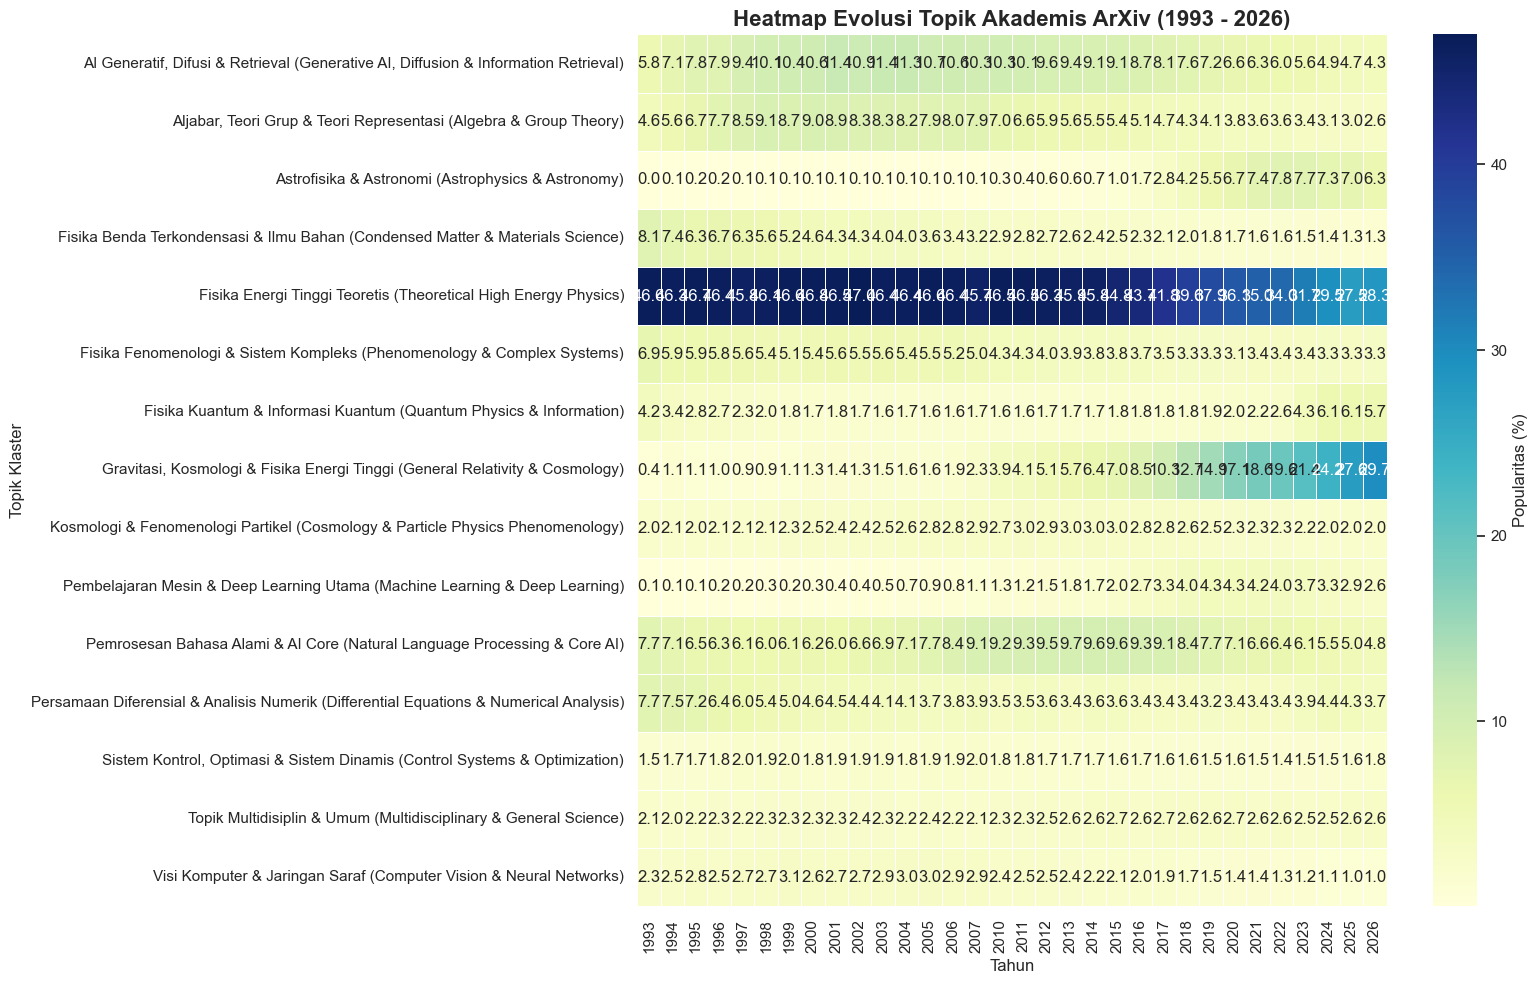

In [7]:
if 'pivot_pct' in locals():
    # Grafik 2: Heatmap Tren Temporal
    plt.figure(figsize=(16, 10))
    sns.heatmap(pivot_pct.T, cmap="YlGnBu", annot=True, fmt=".1f", linewidths=0.5, cbar_kws={'label': 'Popularitas (%)'})
    plt.title("Heatmap Evolusi Topik Akademis ArXiv (1993 - 2026)", fontsize=16, fontweight='bold')
    plt.xlabel("Tahun", fontsize=12)
    plt.ylabel("Topik Klaster", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "trend_heatmap.png"), dpi=300)
    plt.show()

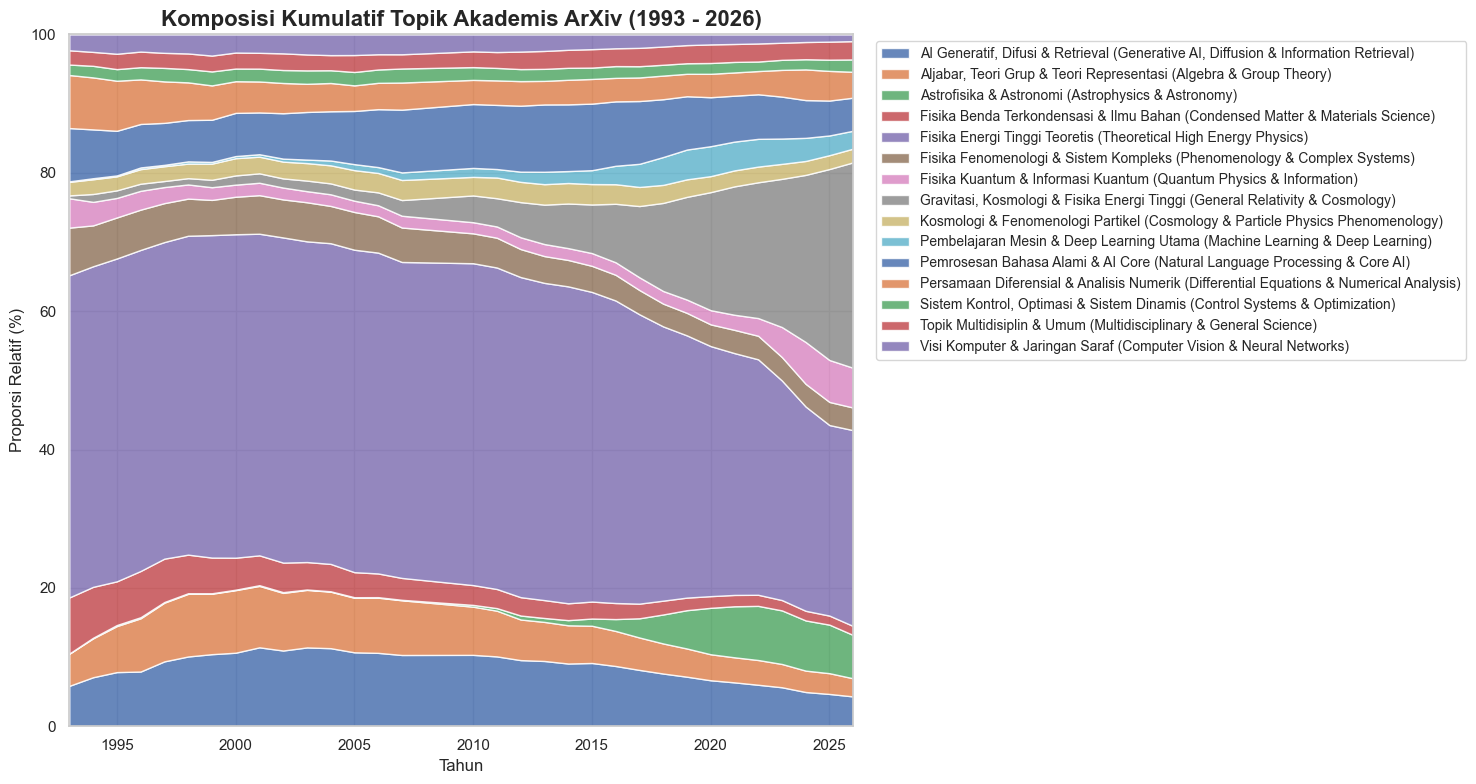

In [8]:
if 'pivot_pct' in locals():
    # Grafik 3: Stacked Area Chart
    plt.figure(figsize=(15, 8))
    plt.stackplot(pivot_pct.index, [pivot_pct[col] for col in pivot_pct.columns], labels=pivot_pct.columns, alpha=0.85)
    plt.title("Komposisi Kumulatif Topik Akademis ArXiv (1993 - 2026)", fontsize=16, fontweight='bold')
    plt.xlabel("Tahun", fontsize=12)
    plt.ylabel("Proporsi Relatif (%)", fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    plt.xlim(1993, 2026)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "trend_stacked_area.png"), dpi=300)
    plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27624\211378485.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=growing.values, y=growing.index, palette="viridis")


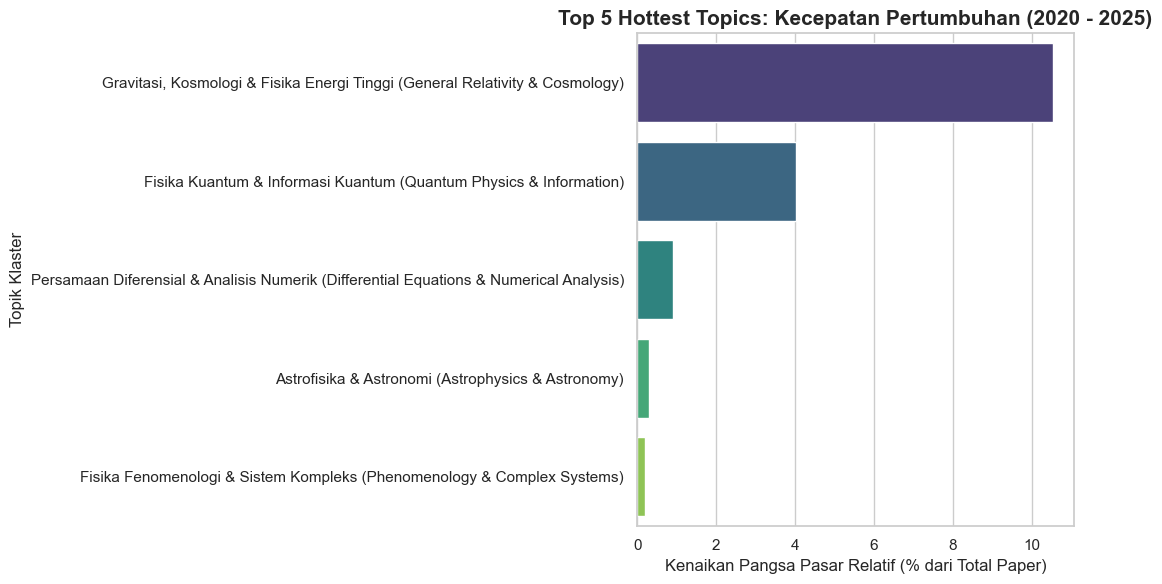

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27624\211378485.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=declining.values, y=declining.index, palette="flare")


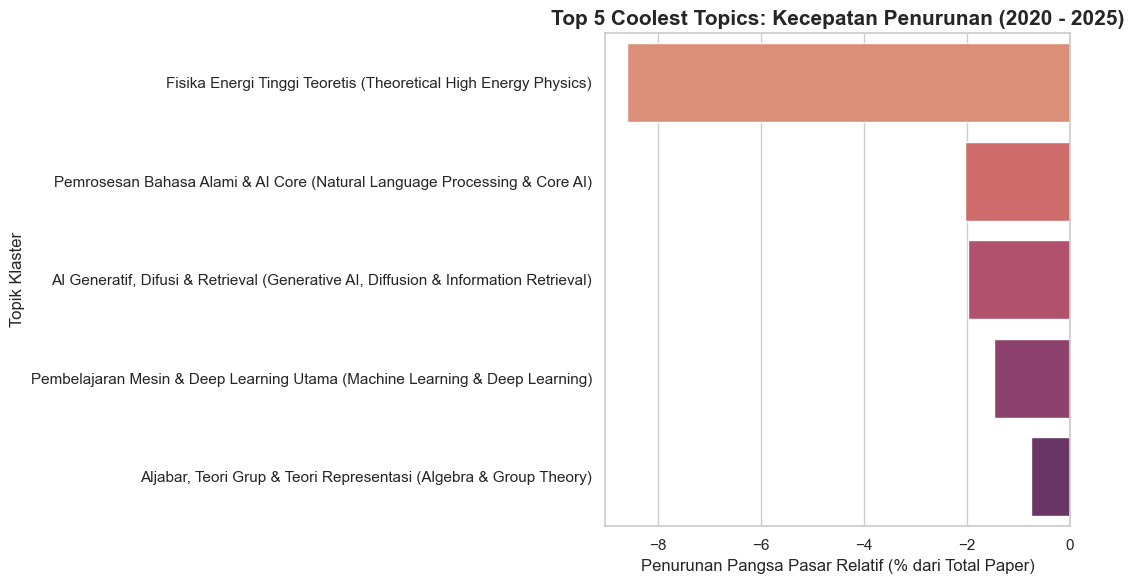

In [9]:
if 'pivot_pct' in locals():
    # Hitung Growth & Decline Velocity (5 tahun terakhir)
    start_yr = 2020
    end_yr = 2025
    
    if start_yr in pivot_pct.index and end_yr in pivot_pct.index:
        diff = pivot_pct.loc[end_yr] - pivot_pct.loc[start_yr]
        growing = diff.sort_values(ascending=False).head(5)
        declining = diff.sort_values(ascending=True).head(5)
        
        # Grafik 4: Top 5 Hottest Topics (Growth)
        plt.figure(figsize=(11, 6))
        sns.barplot(x=growing.values, y=growing.index, palette="viridis")
        plt.title(f"Top 5 Hottest Topics: Kecepatan Pertumbuhan ({start_yr} - {end_yr})", fontsize=15, fontweight='bold')
        plt.xlabel("Kenaikan Pangsa Pasar Relatif (% dari Total Paper)", fontsize=12)
        plt.ylabel("Topik Klaster", fontsize=12)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, "top_growing_topics.png"), dpi=300)
        plt.show()
        
        # Grafik 5: Top 5 Coolest Topics (Decline)
        plt.figure(figsize=(11, 6))
        sns.barplot(x=declining.values, y=declining.index, palette="flare")
        plt.title(f"Top 5 Coolest Topics: Kecepatan Penurunan ({start_yr} - {end_yr})", fontsize=15, fontweight='bold')
        plt.xlabel("Penurunan Pangsa Pasar Relatif (% dari Total Paper)", fontsize=12)
        plt.ylabel("Topik Klaster", fontsize=12)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, "top_declining_topics.png"), dpi=300)
        plt.show()
    else:
        print(f"Tahun {start_yr} atau {end_yr} tidak tersedia di dataset untuk analisis Velocity.")

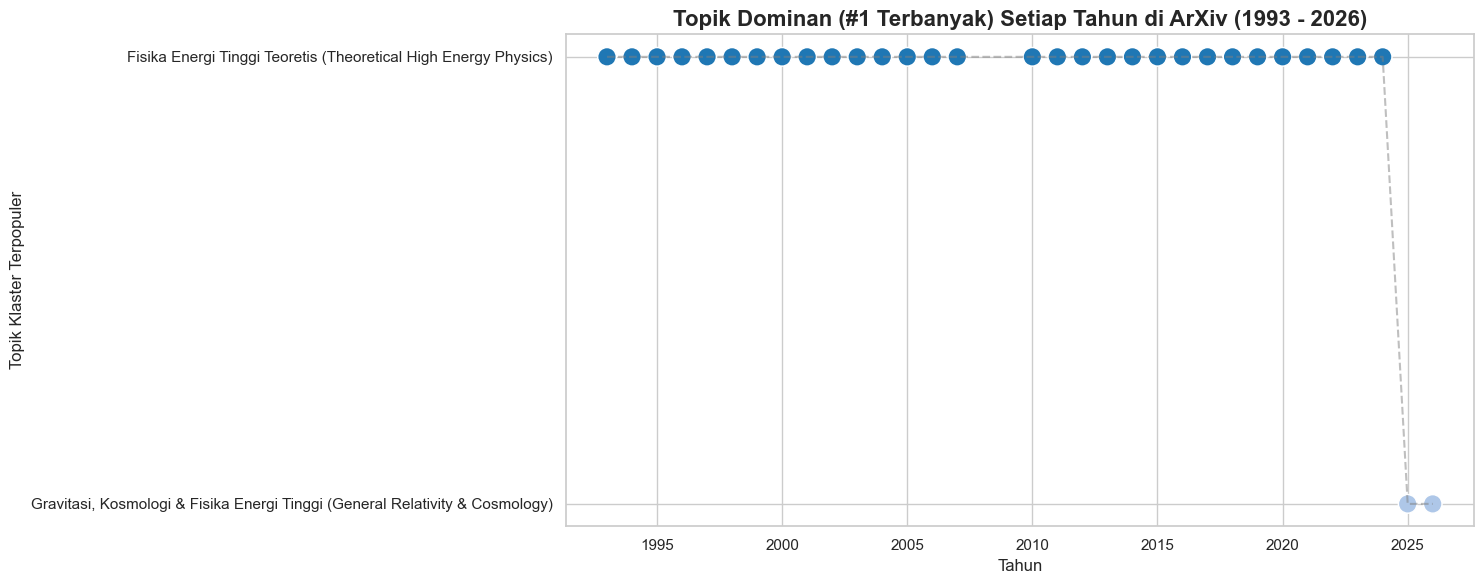

In [10]:
if 'pivot_pct' in locals():
    # Grafik 6: Dominant Topic Timeline
    dominant_topics = pivot_pct.idxmax(axis=1)
    plt.figure(figsize=(15, 6))
    sns.scatterplot(x=dominant_topics.index, y=dominant_topics.values, hue=dominant_topics.values, s=180, legend=False, palette="tab20")
    plt.plot(dominant_topics.index, dominant_topics.values, color="gray", linestyle="--", alpha=0.5)
    plt.title("Topik Dominan (#1 Terbanyak) Setiap Tahun di ArXiv (1993 - 2026)", fontsize=16, fontweight='bold')
    plt.xlabel("Tahun", fontsize=12)
    plt.ylabel("Topik Klaster Terpopuler", fontsize=12)
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "dominant_topic_timeline.png"), dpi=300)
    plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27624\167985499.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='cluster_name', order=order, palette="coolwarm")


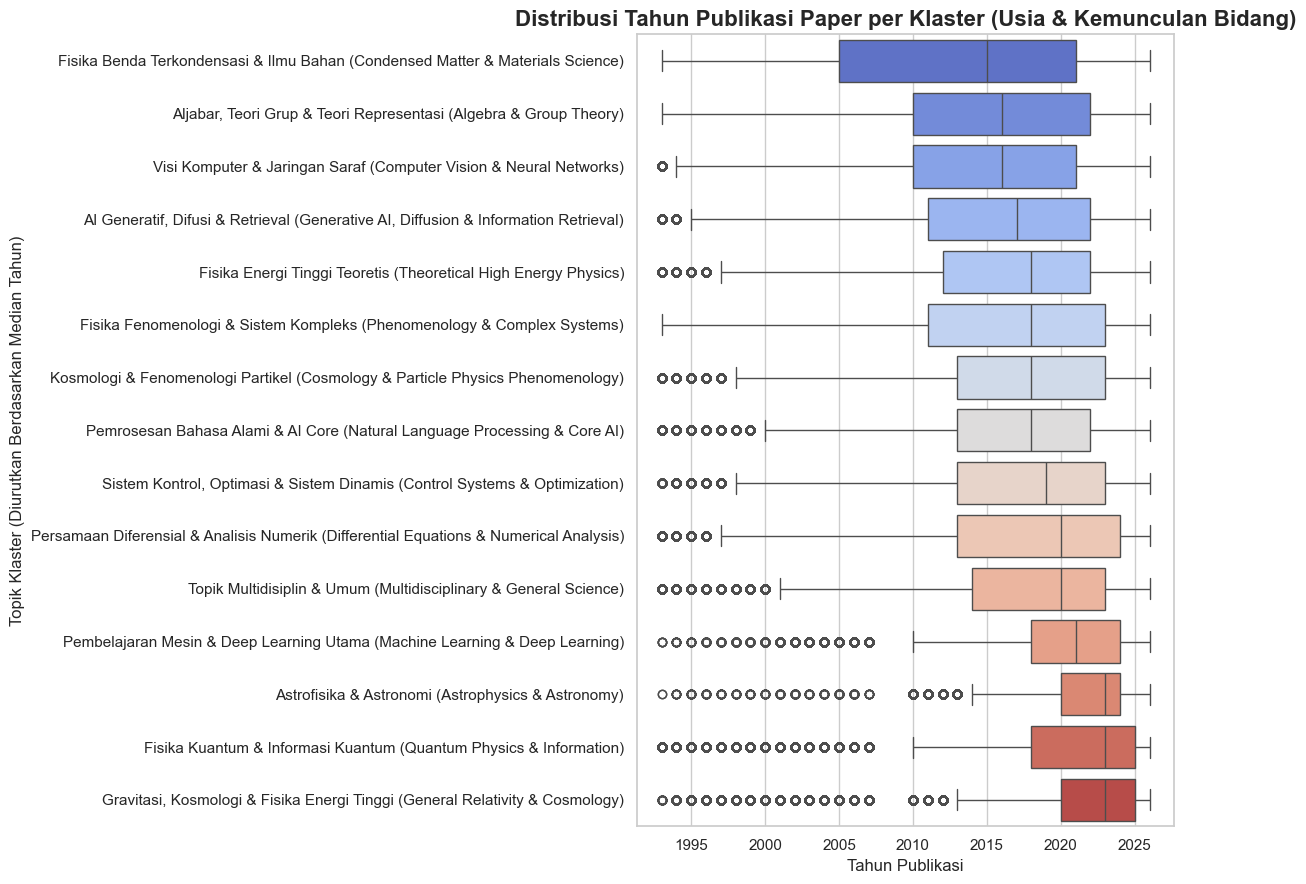

In [11]:
if 'df' in locals():
    # Grafik 7: Cluster Year Distribution (Box Plot)
    plt.figure(figsize=(12, 9))
    # Urutkan klaster berdasarkan median tahun publikasi agar visualisasi rapi
    order = df.groupby('cluster_name')['year'].median().sort_values().index
    sns.boxplot(data=df, x='year', y='cluster_name', order=order, palette="coolwarm")
    plt.title("Distribusi Tahun Publikasi Paper per Klaster (Usia & Kemunculan Bidang)", fontsize=16, fontweight='bold')
    plt.xlabel("Tahun Publikasi", fontsize=12)
    plt.ylabel("Topik Klaster (Diurutkan Berdasarkan Median Tahun)", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "cluster_year_distribution.png"), dpi=300)
    plt.show()

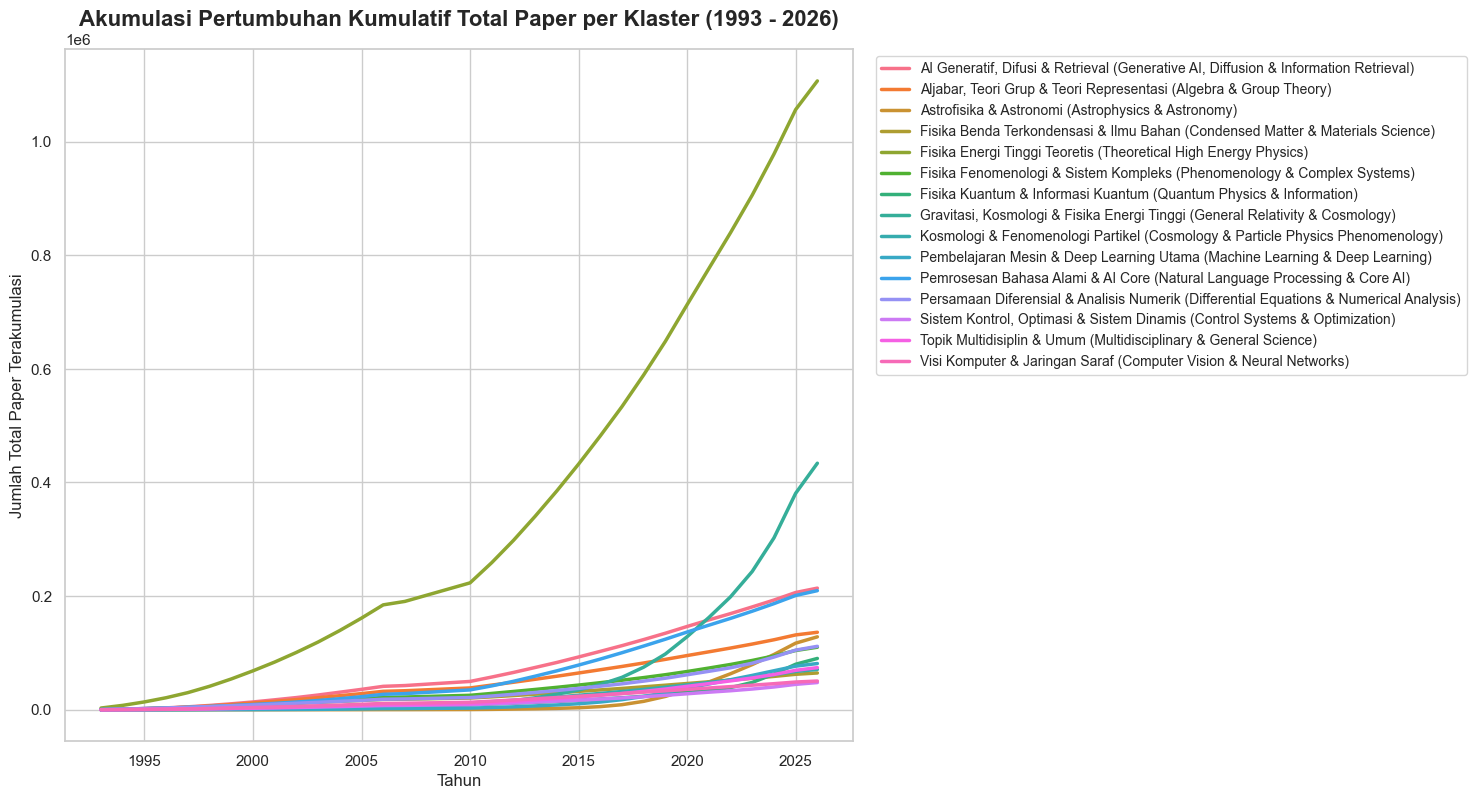

In [12]:
if 'pivot_df' in locals():
    # Grafik 8: Cumulative Growth Line Plot
    pivot_cum = pivot_df.cumsum(axis=0)
    plt.figure(figsize=(15, 8))
    sns.lineplot(data=pivot_cum, dashes=False, linewidth=2.5)
    plt.title("Akumulasi Pertumbuhan Kumulatif Total Paper per Klaster (1993 - 2026)", fontsize=16, fontweight='bold')
    plt.xlabel("Tahun", fontsize=12)
    plt.ylabel("Jumlah Total Paper Terakumulasi", fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "cumulative_growth.png"), dpi=300)
    plt.show()